In [12]:
# Load necessary libraries
import pandas as pd
import nltk
import re

In [13]:
# Download necessary NLTK resources
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/harshavardhank/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [14]:
# Load the CSV file
file_path = '/Users/harshavardhank/Desktop/Code/UPenn/TTQA-Recasting/Benchmark/src/scripts/models/squall_dynamic_response.csv'
data = pd.read_csv(file_path)

In [15]:
# Display the first few rows of the dataframe to understand its structure
data.head()

,Unnamed: 0.1,Unnamed: 0,nt,columns,nl,nl_pos,nl_ner,nl_ralign,nl_typebio,nl_typebio_col,...,question,answer,input_prompt,response,code_output,output,conv_actual_answer,conv_predicted_answer,f1_score,exact
0,0,6954,nt-3635,"[['year of election', ['year', 'of', 'election...","['what', 'was', 'the', 'smallest', 'number', '...","['WP', 'VBD-AUX', 'DT', 'JJS', 'NN', 'IN', 'NN...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'DATE...","[['None', None], ['None', None], ['Keyword', [...","['O', 'O', 'B-Keyword', 'I-Keyword', 'B-Column...","[None, None, None, None, 'c4', 'c4', 'c4', 'c1...",...,what was the smallest number of votes before 2...,"551,009",Instruction\nYou are a meta-reasoner with the ...,"To answer the question ""what was the smallest ...",Final Answer: 551009.0\n,551009 \n,551009.0,551009.0,100.0,100.0
1,1,2576,nt-10718,"[['rank', ['rank'], ['number'], 'number', '1']...","['which', 'country', 'won', 'more', 'total', '...","['WDT', 'NN', 'VBD', 'RBR', 'JJ', 'NNS', 'IN',...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'DATE', 'M...","[['None', None], ['Column', 'c2_first'], ['Non...","['O', 'B-Column', 'O', 'B-Keyword', 'B-Column'...","[None, 'c2', None, None, 'c6', None, None, Non...",...,which country won more total medals than tue f...,Russia,Instruction\nYou are a meta-reasoner with the ...,"To solve the question ""which country won more ...","Error: exec() arg 1 must be a string, bytes or...",Russia \n,russia,russia,100.0,100.0
2,2,1693,nt-5978,"[['genre', ['genre'], [], 'text', 'film'], ['y...","['in', '2013', ',', 'how', 'many', 'films', 'd...","['IN', 'CD', ',', 'WRB', 'JJ', 'NNS', 'VBD-AUX...","['O', 'DATE', 'O', 'O', 'O', 'O', 'O', 'O', 'O...","[['Column', 'c2_number'], ['Literal', None], [...","['B-Column', 'Number', 'O', 'B-Keyword', 'I-Ke...","['c2', 'c2_number', None, None, None, 'c3', No...",...,"in 2013 , how many films did domingo appear in ?",4,Instruction\nYou are a meta-reasoner with the ...,"To answer the question ""in 2013, how many film...","Error: exec() arg 1 must be a string, bytes or...",3 \n,4.0,3.0,0.0,0.0
3,3,1597,nt-6397,"[['position', ['position'], ['number'], 'numbe...","['how', 'many', 'more', 'points', 'did', 'jan'...","['WRB', 'JJ', 'JJR', 'NNS', 'VBD-AUX', 'NNP', ...","['O', 'O', 'O', 'O', 'O', 'PERSON', 'PERSON', ...","[['Keyword', ['diff', '']], ['Keyword', ['diff...","['B-Keyword', 'I-Keyword', 'I-Keyword', 'B-Col...","[None, None, None, 'c4', None, 'c2_list', 'c2_...",...,how many more points did jan hendrickx have th...,106,Instruction\nYou are a meta-reasoner with the ...,"To answer the question ""how many more points d...",Final Answer: 3.0\n,3 \n,106.0,3.0,0.0,0.0
4,4,5187,nt-10570,"[['edition', ['edition'], ['number'], 'rank', ...","['what', 'is', 'the', 'number', 'of', 'times',...","['WP', 'VBD-AUX', 'DT', 'NN', 'IN', 'NNS', 'DT...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...","[['None', None], ['None', None], ['Keyword', [...","['O', 'O', 'B-Keyword', 'I-Keyword', 'I-Keywor...","[None, None, None, None, None, None, None, Non...",...,what is the number of times the eindhoven mara...,30,Instruction\nYou are a meta-reasoner with the ...,"To solve the question ""what is the number of t...","Error: exec() arg 1 must be a string, bytes or...",Not enough information provided. \n,30.0,not enough information provided,0.0,0.0


In [16]:
# Analyze the 'response' column to understand its content and structure
response_data = data['response']

In [17]:
# Display the first few rows of the 'response' column
response_data.head()

0    To answer the question "what was the smallest ...
1    To solve the question "which country won more ...
2    To answer the question "in 2013, how many film...
3    To answer the question "how many more points d...
4    To solve the question "what is the number of t...
Name: response, dtype: object

In [18]:
# Function to summarize the response patterns
def summarize_response_patterns(responses):
    # Initialize pattern counters
    patterns = {
        "To answer the question": 0,
        "To solve the question": 0,
        "To address the question": 0,
        "Other": 0
    }
    
    for response in responses:
        if response.startswith("To answer the question"):
            patterns["To answer the question"] += 1
        elif response.startswith("To solve the question"):
            patterns["To solve the question"] += 1
        elif response.startswith("To address the question"):
            patterns["To address the question"] += 1
        else:
            patterns["Other"] += 1
    
    return patterns

In [19]:
# Summarize response patterns in the 'response' column
response_patterns = summarize_response_patterns(response_data)
response_patterns

AttributeError: 'float' object has no attribute 'startswith'

In [20]:
# Define reasoning process keywords and patterns
patterns = {
    "Extract Relevant Information": re.compile(r"extract|relevant information", re.IGNORECASE),
    "Decomposition of Problem": re.compile(r"decompose|sub-problem", re.IGNORECASE),
    "Individually Answer Each Sub-Problem": re.compile(r"answer each|individual", re.IGNORECASE),
    "Write a Python Program": re.compile(r"python program|code|script", re.IGNORECASE)
}

In [21]:
# Function to categorize reasoning processes in a response
def categorize_response(response):
    sentences = response.split('.')
    reasoning_methods = set()
    
    for sentence in sentences:
        for method, pattern in patterns.items():
            if pattern.search(sentence):
                reasoning_methods.add(method)
    
    return reasoning_methods

In [22]:
# Apply the categorization to the 'response' column
data['reasoning_methods'] = data['response'].apply(lambda x: categorize_response(str(x)) if pd.notnull(x) else set())

In [23]:
# Summarize the response patterns
reasoning_summary = data['reasoning_methods'].explode().value_counts()
reasoning_summary

reasoning_methods
Extract Relevant Information            768
Write a Python Program                  553
Individually Answer Each Sub-Problem    456
Decomposition of Problem                453
Name: count, dtype: int64

In [24]:
# Function to check if all reasoning methods are used in a response
def uses_all_methods(methods_set):
    return all(method in methods_set for method in patterns.keys())

In [25]:
# Count the number of rows that utilize all reasoning methods
all_methods_count = data['reasoning_methods'].apply(uses_all_methods).sum()
all_methods_count

267

In [26]:
# Identify rows that do not use the "Extract Relevant Information" method
rows_without_extraction = data[~data['reasoning_methods'].apply(lambda methods: "Extract Relevant Information" in methods)]

In [27]:
# Display the indices of these rows
rows_without_extraction_indices = rows_without_extraction.index.tolist()
rows_without_extraction_indices

[40, 529, 572, 631, 713, 714]

In [28]:
# Display the rows that do not use the "Extract Relevant Information" method
rows_without_extraction_details = data.loc[rows_without_extraction_indices]
filtered_data = rows_without_extraction_details[['response', 'f1_score', 'nl']]

In [29]:
# Rename 'nl' to 'question' for clarity
filtered_data = filtered_data.rename(columns={'nl': 'question'})
filtered_data

,response,f1_score,question
40,NaN,0.0,"['which', 'song', 'did', 'he', 'make', 'after'..."
529,NaN,0.0,"['which', 'monarch', 'is', 'listed', 'first', ..."
572,NaN,0.0,"['how', 'long', 'is', 'the', 'intro', '?']"
631,**Problem Understanding:**\n\n1. **Determine t...,0.0,"['what', 'is', 'the', 'number', 'of', 'times',..."
713,NaN,0.0,"['how', 'many', 'times', 'did', 'mocho', 'cota..."
714,NaN,0.0,"['how', 'many', 'movies', 'was', 'she', 'in', ..."


In [30]:
# Get the total number of rows in the original dataset
total_rows_original = data.shape[0]
total_rows_original

774

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/harshavardhank/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


reasoning_methods
Extract Relevant Information            768
Write a Python Program                  553
Individually Answer Each Sub-Problem    456
Decomposition of Problem                453
Name: count, dtype: int64
Number of rows that use all reasoning methods: 267
                                              response  f1_score  \
40                                                 NaN       0.0   
529                                                NaN       0.0   
572                                                NaN       0.0   
631  **Problem Understanding:**\n\n1. **Determine t...       0.0   
713                                                NaN       0.0   
714                                                NaN       0.0   

                                              question  
40   ['which', 'song', 'did', 'he', 'make', 'after'...  
529  ['which', 'monarch', 'is', 'listed', 'first', ...  
572         ['how', 'long', 'is', 'the', 'intro', '?']  
631  ['what', 'is', 'the

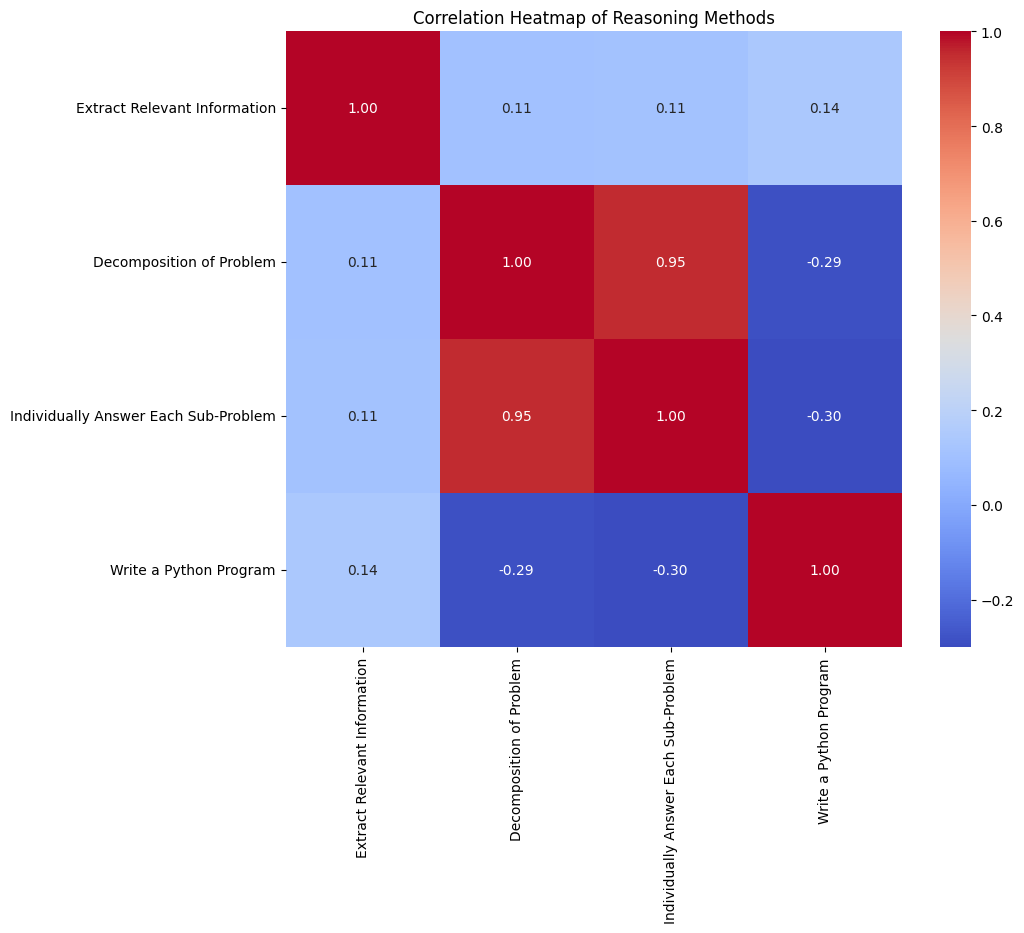

The second most used method alongside 'Extract Relevant Information' is: Write a Python Program


In [31]:
# Load necessary libraries
import pandas as pd
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Download necessary NLTK resources
nltk.download('punkt')

# Load the CSV file
file_path = '/Users/harshavardhank/Desktop/Code/UPenn/TTQA-Recasting/Benchmark/src/scripts/models/squall_dynamic_response.csv'
data = pd.read_csv(file_path)

# Display the first few rows of the dataframe to understand its structure
data.head()

# Define reasoning process keywords and patterns
patterns = {
    "Extract Relevant Information": re.compile(r"extract|relevant information", re.IGNORECASE),
    "Decomposition of Problem": re.compile(r"decompose|sub-problem", re.IGNORECASE),
    "Individually Answer Each Sub-Problem": re.compile(r"answer each|individual", re.IGNORECASE),
    "Write a Python Program": re.compile(r"python program|code|script", re.IGNORECASE)
}

# Function to categorize reasoning processes in a response
def categorize_response(response):
    sentences = response.split('.')
    reasoning_methods = set()
    
    for sentence in sentences:
        for method, pattern in patterns.items():
            if pattern.search(sentence):
                reasoning_methods.add(method)
    
    return reasoning_methods

# Apply the categorization to the 'response' column
data['reasoning_methods'] = data['response'].apply(lambda x: categorize_response(str(x)) if pd.notnull(x) else set())

# Summarize the response patterns
reasoning_summary = data['reasoning_methods'].explode().value_counts()
print(reasoning_summary)

# Function to check if all reasoning methods are used in a response
def uses_all_methods(methods_set):
    return all(method in methods_set for method in patterns.keys())

# Count the number of rows that utilize all reasoning methods
all_methods_count = data['reasoning_methods'].apply(uses_all_methods).sum()
print("Number of rows that use all reasoning methods:", all_methods_count)

# Identify rows that do not use the "Extract Relevant Information" method
rows_without_extraction = data[~data['reasoning_methods'].apply(lambda methods: "Extract Relevant Information" in methods)]
rows_without_extraction_details = rows_without_extraction[['response', 'f1_score', 'nl']].rename(columns={'nl': 'question'})
print(rows_without_extraction_details)

# Generate a correlation heatmap for the methods used
# Create a new DataFrame with binary indicators for each reasoning method
methods_df = pd.DataFrame()
for method in patterns.keys():
    methods_df[method] = data['reasoning_methods'].apply(lambda x: 1 if method in x else 0)

# Calculate the correlation matrix
correlation_matrix = methods_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', cbar=True, square=True, fmt=".2f")
plt.title('Correlation Heatmap of Reasoning Methods')
plt.show()

# Identify the second method used with "Extract Relevant Information"
extract_info_rows = data[data['reasoning_methods'].apply(lambda x: "Extract Relevant Information" in x)]
remaining_methods = extract_info_rows['reasoning_methods'].apply(lambda x: x - {"Extract Relevant Information"}).explode()
second_method = remaining_methods.value_counts().idxmax()
print("The second most used method alongside 'Extract Relevant Information' is:", second_method)

# Save the resultant CSV
resultant_csv = data[['response', 'f1_score', 'nl', 'reasoning_methods']].rename(columns={'nl': 'question'})
resultant_csv.to_csv('squall_resultant.csv', index=False)


Reasoning Methods Summary:
 reasoning_methods
Extract Relevant Information            768
Write a Python Program                  557
Individually Answer Each Sub-Problem    456
Decomposition of Problem                453
Name: count, dtype: int64
Number of rows that use all reasoning methods: 270
Rows without 'Extract Relevant Information':
                                               response  f1_score  \
40                                                 NaN       0.0   
529                                                NaN       0.0   
572                                                NaN       0.0   
631  **Problem Understanding:**\n\n1. **Determine t...       0.0   
713                                                NaN       0.0   
714                                                NaN       0.0   

                                              question  
40   ['which', 'song', 'did', 'he', 'make', 'after'...  
529  ['which', 'monarch', 'is', 'listed', 'first', ...  
572    

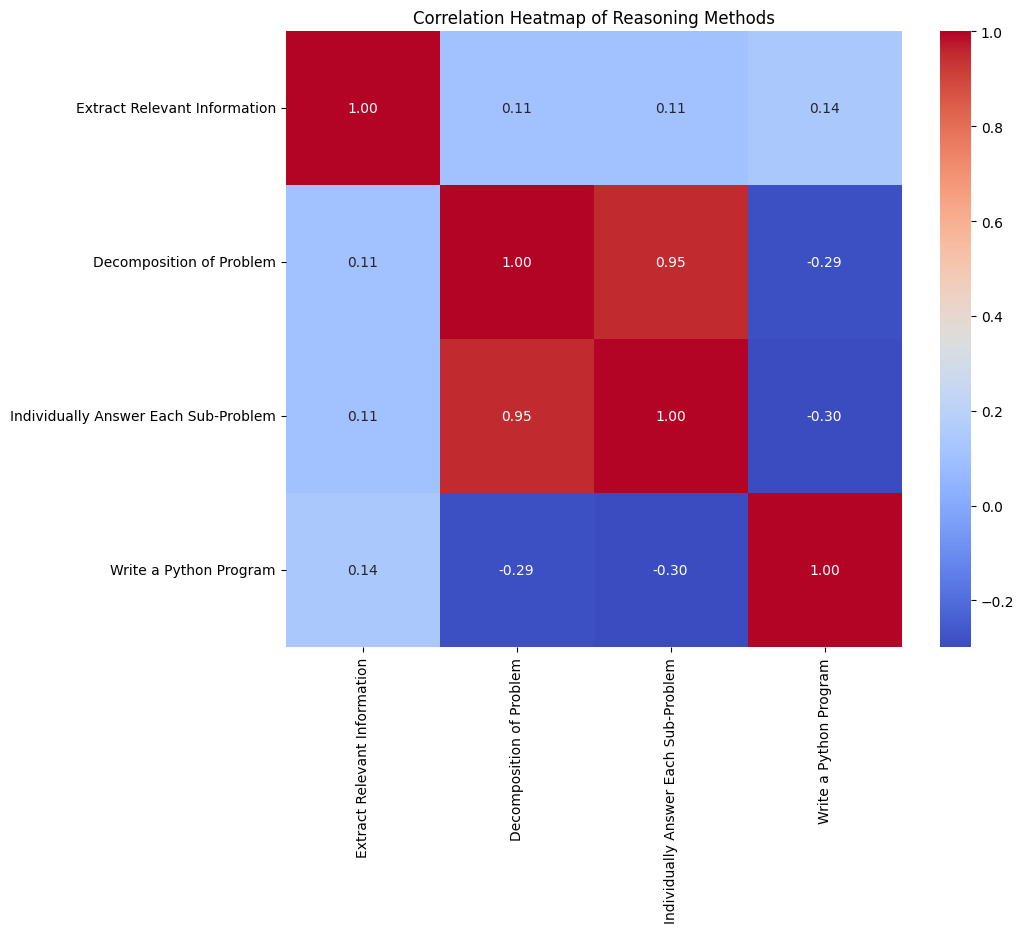

In [32]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
file_path = '/Users/harshavardhank/Desktop/Code/UPenn/TTQA-Recasting/Benchmark/src/scripts/models/squall_dynamic_response.csv'
data = pd.read_csv(file_path)

# Define reasoning process keywords and patterns
patterns = {
    "Extract Relevant Information": re.compile(r"extract|relevant information", re.IGNORECASE),
    "Decomposition of Problem": re.compile(r"decompose|sub-problem", re.IGNORECASE),
    "Individually Answer Each Sub-Problem": re.compile(r"answer each|individual", re.IGNORECASE),
    "Write a Python Program": re.compile(r"python program|code|script|# Done|# Print", re.IGNORECASE)
}

# Function to categorize reasoning processes in a response
def categorize_response(response):
    sentences = response.split('.')
    reasoning_methods = set()
    
    for sentence in sentences:
        for method, pattern in patterns.items():
            if pattern.search(sentence):
                reasoning_methods.add(method)
    
    return reasoning_methods

# Apply the categorization to the 'response' column
data['reasoning_methods'] = data['response'].apply(lambda x: categorize_response(str(x)) if pd.notnull(x) else set())

# Summarize the response patterns
reasoning_summary = data['reasoning_methods'].explode().value_counts()
print("Reasoning Methods Summary:\n", reasoning_summary)

# Function to check if all reasoning methods are used in a response
def uses_all_methods(methods_set):
    return all(method in methods_set for method in patterns.keys())

# Count the number of rows that utilize all reasoning methods
all_methods_count = data['reasoning_methods'].apply(uses_all_methods).sum()
print("Number of rows that use all reasoning methods:", all_methods_count)

# Identify rows that do not use the "Extract Relevant Information" method
rows_without_extraction = data[~data['reasoning_methods'].apply(lambda methods: "Extract Relevant Information" in methods)]
rows_without_extraction_details = rows_without_extraction[['response', 'f1_score', 'nl']].rename(columns={'nl': 'question'})
print("Rows without 'Extract Relevant Information':\n", rows_without_extraction_details)

# Generate a correlation heatmap for the methods used
# Create a new DataFrame with binary indicators for each reasoning method
methods_df = pd.DataFrame()
for method in patterns.keys():
    methods_df[method] = data['reasoning_methods'].apply(lambda x: 1 if method in x else 0)

# Calculate the correlation matrix
correlation_matrix = methods_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', cbar=True, square=True, fmt=".2f")
plt.title('Correlation Heatmap of Reasoning Methods')
plt.show()


In [33]:
import pandas as pd
import re

# Load the CSV file
file_path = '/Users/harshavardhank/Desktop/Code/UPenn/TTQA-Recasting/Benchmark/src/scripts/models/squall_dynamic_response.csv'
data = pd.read_csv(file_path)

# Define reasoning process keywords and patterns
patterns = {
    "Extract Relevant Information": re.compile(r"extract|relevant information", re.IGNORECASE),
    "Decomposition of Problem": re.compile(r"decompose|sub-problem", re.IGNORECASE),
    "Individually Answer Each Sub-Problem": re.compile(r"answer each|individual", re.IGNORECASE),
    "Write a Python Program": re.compile(r"python program|code|script|# Done|# Print", re.IGNORECASE)
}

# Function to categorize reasoning processes in a response
def categorize_response(response):
    sentences = response.split('.')
    reasoning_methods = set()
    
    for sentence in sentences:
        for method, pattern in patterns.items():
            if pattern.search(sentence):
                reasoning_methods.add(method)
    
    return reasoning_methods

# Apply the categorization to the 'response' column
data['reasoning_methods'] = data['response'].apply(lambda x: categorize_response(str(x)) if pd.notnull(x) else set())

# Count the number of methods used per response
data['num_methods'] = data['reasoning_methods'].apply(len)

# Count the number of responses using more than one method
more_than_one_method_count = data[data['num_methods'] > 1].shape[0]

# Complete breakdown of the number of methods used
methods_breakdown = data['num_methods'].value_counts()

print("Number of responses using more than one method:", more_than_one_method_count)
print("Complete breakdown of the number of methods used:\n", methods_breakdown)


Number of responses using more than one method: 737
Complete breakdown of the number of methods used:
 num_methods
2    278
4    270
3    189
1     31
0      6
Name: count, dtype: int64
